# ------------------------ Evaluate and select the final model ------------------------

### Importing important packages

In [1]:
# ============================================================
# EUROEATS — EVALUATE & SELECT FINAL MODEL
# BLOCK 1 — IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt
import math as math
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline


from sklearn.model_selection import (
    cross_val_score,
    KFold,
    GridSearchCV
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from scipy import stats

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# ============================================================
# BLOCK 2 — LOAD PREPARED ML DATA
# ============================================================

ml_data = pd.read_pickle(
    "EuroEats_ML_prepared_data.pkl"
)

X_train = ml_data["X_train"]
X_test = ml_data["X_test"]

y_train = ml_data["y_train"]
y_test = ml_data["y_test"]

numeric_features = ml_data["numeric_features"]
categorical_features = ml_data["categorical_features"]

print("Training features:", X_train.shape)
print("Testing features :", X_test.shape)

print("Training target:", y_train.shape)
print("Testing target :", y_test.shape)

Training features: (800, 27)
Testing features : (200, 27)
Training target: (800,)
Testing target : (200,)


In [3]:
# ============================================================
# BLOCK 3 — LOAD BASELINE MODELS
# ============================================================

baseline_data = pd.read_pickle(
    "EuroEats_baseline_models.pkl"
)

trained_models = baseline_data[
    "trained_models"
]

results_df = baseline_data[
    "results_df"
]

print("Baseline models loaded successfully.")

print("\nBaseline results:")
print(
    results_df.round(3)
)

Baseline models loaded successfully.

Baseline results:
               Model  Train MAE  Test MAE  Train RMSE  Test RMSE  Train R²  \
0      Random Forest      1.510     4.524       2.224      7.042     0.987   
1  Gradient Boosting      2.677     4.550       3.569      7.088     0.966   
2  Linear Regression      4.791     5.115       7.277      7.520     0.859   
3      Decision Tree      0.000     5.902       0.000      8.903     1.000   

   Test R²  
0    0.888  
1    0.887  
2    0.873  
3    0.821  


In [4]:
# ============================================================
# BLOCK 4 — LINEAR REGRESSION ASSUMPTION CHECK
#
# Assumptions evaluated:
# 1. Linearity
# 2. Homoscedasticity
# 3. Normality of residuals
# 4. Independence
# ============================================================

linear_model = trained_models[
    "Linear Regression"
]

# Predictions
y_train_pred_lr = linear_model.predict(
    X_train
)

y_test_pred_lr = linear_model.predict(
    X_test
)

# Residuals
train_residuals_lr = (
    y_train - y_train_pred_lr
)

test_residuals_lr = (
    y_test - y_test_pred_lr
)

print("Linear Regression diagnostics prepared.")

Linear Regression diagnostics prepared.


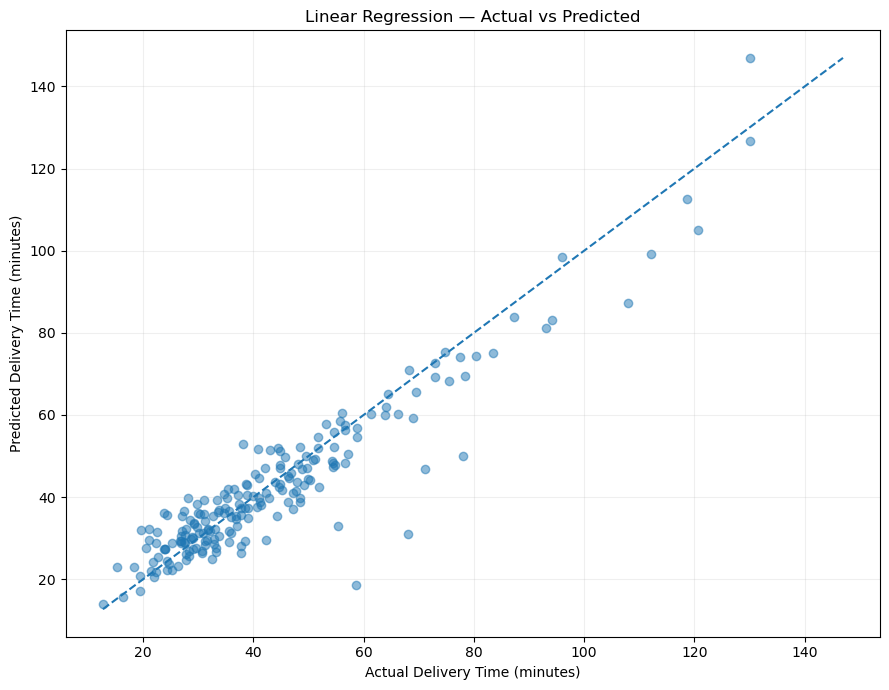

In [5]:
# ============================================================
# BLOCK 5 — LINEARITY CHECK
# ACTUAL VS PREDICTED
# ============================================================

plt.figure(
    figsize=(9, 7)
)

plt.scatter(
    y_test,
    y_test_pred_lr,
    alpha=0.5
)

min_value = min(
    y_test.min(),
    y_test_pred_lr.min()
)

max_value = max(
    y_test.max(),
    y_test_pred_lr.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel(
    "Actual Delivery Time (minutes)"
)

plt.ylabel(
    "Predicted Delivery Time (minutes)"
)

plt.title(
    "Linear Regression — Actual vs Predicted"
)

plt.grid(
    alpha=0.2
)

plt.tight_layout()
plt.show()

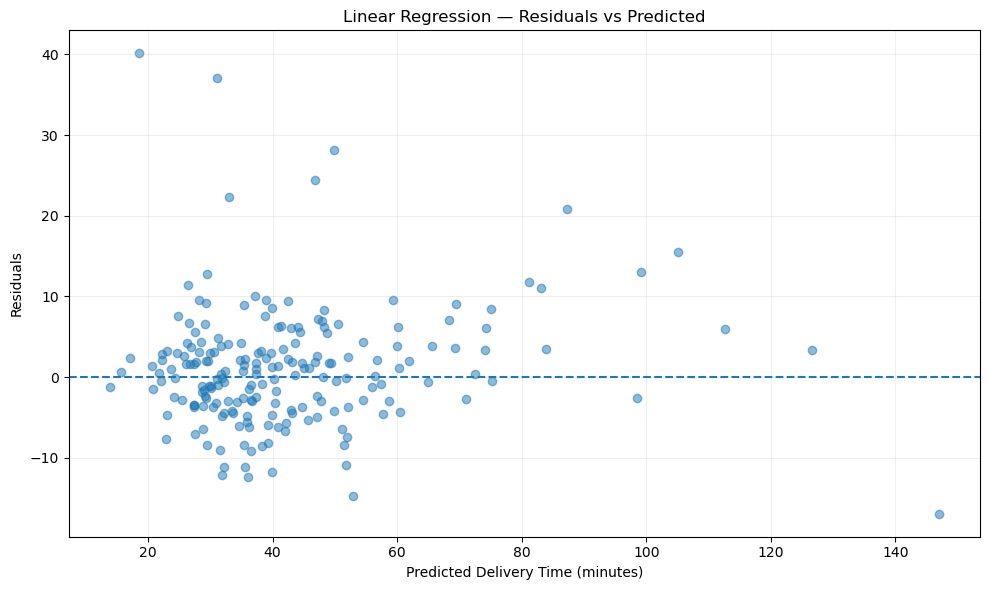

In [6]:
# ============================================================
# BLOCK 6 — HOMOSCEDASTICITY CHECK
# RESIDUALS VS PREDICTED
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.scatter(
    y_test_pred_lr,
    test_residuals_lr,
    alpha=0.5
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel(
    "Predicted Delivery Time (minutes)"
)

plt.ylabel(
    "Residuals"
)

plt.title(
    "Linear Regression — Residuals vs Predicted"
)

plt.grid(
    alpha=0.2
)

plt.tight_layout()
plt.show()

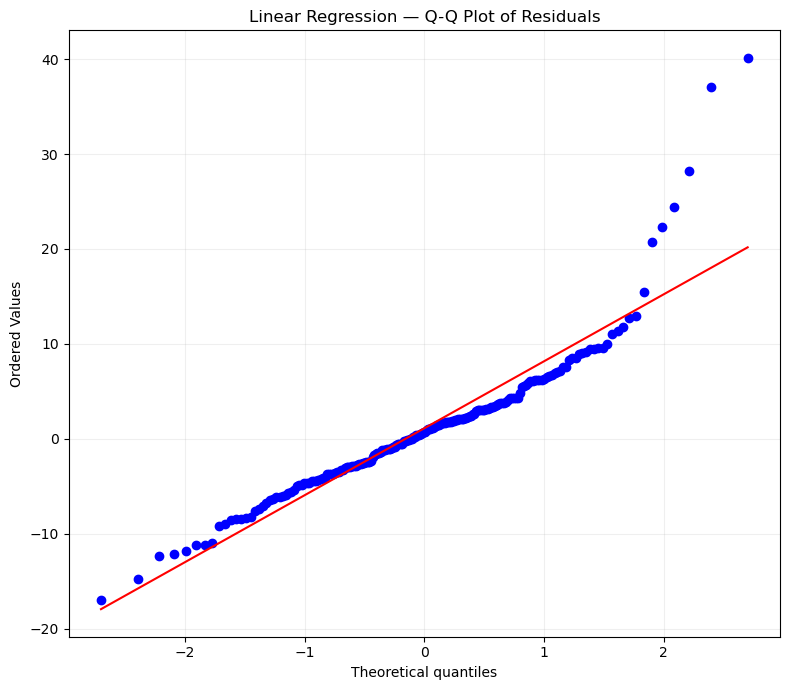

In [7]:
# ============================================================
# BLOCK 7 — NORMALITY OF RESIDUALS
# Q-Q PLOT
# ============================================================

plt.figure(
    figsize=(8, 7)
)

stats.probplot(
    test_residuals_lr,
    dist="norm",
    plot=plt
)

plt.title(
    "Linear Regression — Q-Q Plot of Residuals"
)

plt.grid(
    alpha=0.2
)

plt.tight_layout()
plt.show()

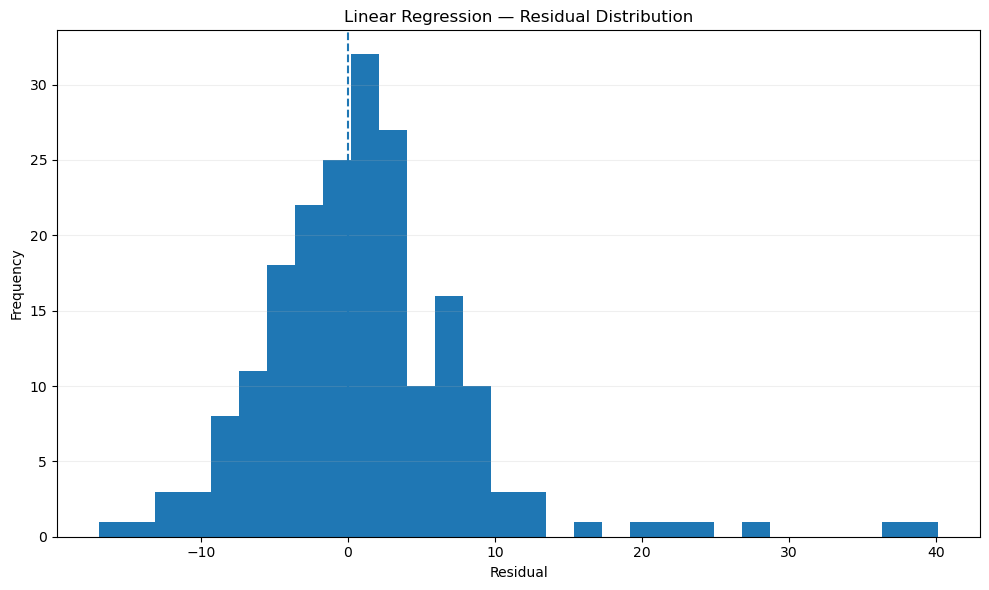

In [8]:
# ============================================================
# BLOCK 8 — RESIDUAL DISTRIBUTION
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.hist(
    test_residuals_lr,
    bins=30
)

plt.axvline(
    x=0,
    linestyle="--"
)

plt.xlabel(
    "Residual"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "Linear Regression — Residual Distribution"
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()
plt.show()

In [9]:
# ============================================================
# BLOCK 9 — CROSS-VALIDATION
# ============================================================

candidate_model_names = [
    "Random Forest",
    "Gradient Boosting",
    "Linear Regression"
]

candidate_models = {
    name: trained_models[name]
    for name in candidate_model_names
}

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for model_name, model in candidate_models.items():

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="neg_mean_absolute_error",
        n_jobs=-1
    )

    mae_scores = -scores

    cv_results.append({
        "Model": model_name,
        "CV MAE Mean": mae_scores.mean(),
        "CV MAE Std": mae_scores.std()
    })

cv_results_df = pd.DataFrame(
    cv_results
).sort_values(
    "CV MAE Mean"
)

print(
    cv_results_df.round(3)
)

               Model  CV MAE Mean  CV MAE Std
0      Random Forest        4.097       0.175
1  Gradient Boosting        4.135       0.187
2  Linear Regression        5.522       0.288


In [10]:
# ============================================================
# BLOCK 10 — RANDOM FOREST HYPERPARAMETER TUNING
# ============================================================

rf_model = trained_models[
    "Random Forest"
]

rf_params = {
    "model__n_estimators": [100, 150],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

rf_grid = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_params,
    cv=3,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(
    X_train,
    y_train
)

print(
    "Best Random Forest parameters:"
)

print(
    rf_grid.best_params_
)

print(
    "\nBest CV MAE:",
    round(
        -rf_grid.best_score_,
        3
    )
)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Random Forest parameters:
{'model__max_depth': 20, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 150}

Best CV MAE: 4.111


In [11]:
# ============================================================
# BLOCK 11 — GRADIENT BOOSTING HYPERPARAMETER TUNING
# ============================================================

gb_model = trained_models[
    "Gradient Boosting"
]

gb_params = {
    "model__n_estimators": [100, 150],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [2, 3],
    "model__min_samples_split": [2, 5]
}

gb_grid = GridSearchCV(
    estimator=gb_model,
    param_grid=gb_params,
    cv=3,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

gb_grid.fit(
    X_train,
    y_train
)

print(
    "Best Gradient Boosting parameters:"
)

print(
    gb_grid.best_params_
)

print(
    "\nBest CV MAE:",
    round(
        -gb_grid.best_score_,
        3
    )
)

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best Gradient Boosting parameters:
{'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__min_samples_split': 2, 'model__n_estimators': 100}

Best CV MAE: 4.081


In [12]:
# ============================================================
# BLOCK 12 — COMPARE TUNED MODELS
# ============================================================

tuned_models = {
    "Random Forest Tuned":
        rf_grid.best_estimator_,

    "Gradient Boosting Tuned":
        gb_grid.best_estimator_,

    "Linear Regression":
        trained_models["Linear Regression"]
}

tuned_results = []

for model_name, model in tuned_models.items():

    train_pred = model.predict(
        X_train
    )

    test_pred = model.predict(
        X_test
    )

    tuned_results.append({

        "Model": model_name,

        "Train MAE":
            mean_absolute_error(
                y_train,
                train_pred
            ),

        "Test MAE":
            mean_absolute_error(
                y_test,
                test_pred
            ),

        "Train RMSE":
            np.sqrt(
                mean_squared_error(
                    y_train,
                    train_pred
                )
            ),

        "Test RMSE":
            np.sqrt(
                mean_squared_error(
                    y_test,
                    test_pred
                )
            ),

        "Train R²":
            r2_score(
                y_train,
                train_pred
            ),

        "Test R²":
            r2_score(
                y_test,
                test_pred
            )
    })

tuned_results_df = pd.DataFrame(
    tuned_results
).sort_values(
    "Test MAE"
)

tuned_results_df.round(3)

,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R²,Test R²
1,Gradient Boosting Tuned,3.165,4.314,4.412,6.876,0.948,0.893
0,Random Forest Tuned,1.846,4.473,3.137,7.029,0.974,0.889
2,Linear Regression,4.791,5.115,7.277,7.520,0.859,0.873


In [13]:
# ============================================================
# BLOCK 13 — FINAL MODEL COMPARISON
# ============================================================

print(
    "FINAL MODEL COMPARISON"
)

print(
    tuned_results_df.round(3)
)

FINAL MODEL COMPARISON
                     Model  Train MAE  Test MAE  Train RMSE  Test RMSE  \
1  Gradient Boosting Tuned      3.165     4.314       4.412      6.876   
0      Random Forest Tuned      1.846     4.473       3.137      7.029   
2        Linear Regression      4.791     5.115       7.277      7.520   

   Train R²  Test R²  
1     0.948    0.893  
0     0.974    0.889  
2     0.859    0.873  


In [14]:
# ============================================================
# BLOCK 14 — SET FINAL MODEL
# ============================================================

# CHANGE THIS AFTER REVIEWING tuned_results_df

final_model = rf_grid.best_estimator_

print(
    "Final model selected:"
)

print(
    "Random Forest — Tuned"
)

Final model selected:
Random Forest — Tuned


In [15]:
# ============================================================
# BLOCK 14 — SET FINAL MODEL
# ============================================================

# CHANGE THIS AFTER REVIEWING tuned_results_df

final_model = rf_grid.best_estimator_

print(
    "Final model selected:"
)

print(
    "Random Forest — Tuned"
)

Final model selected:
Random Forest — Tuned


In [17]:
# ============================================================
# BLOCK 15 — FINAL MODEL EVALUATION
# ============================================================

final_train_pred = final_model.predict(X_train)
final_test_pred = final_model.predict(X_test)

# Test metrics
final_mae = mean_absolute_error(y_test, final_test_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, final_test_pred))
final_r2 = r2_score(y_test, final_test_pred)

print("Final Model Performance")
print("-" * 40)
print(f"Test MAE  : {final_mae:.3f} minutes")
print(f"Test RMSE : {final_rmse:.3f} minutes")
print(f"Test R²   : {final_r2:.3f}")

Final Model Performance
----------------------------------------
Test MAE  : 4.473 minutes
Test RMSE : 7.029 minutes
Test R²   : 0.889


<Figure size 900x700 with 0 Axes>

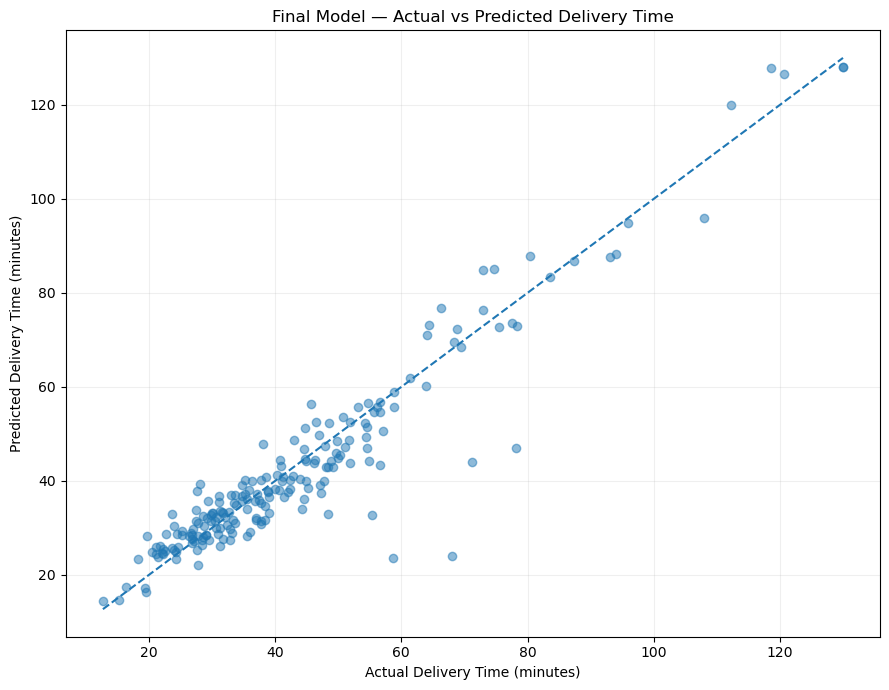

In [18]:
# ============================================================
# BLOCK 16 — FINAL MODEL
# ACTUAL VS PREDICTED
# ============================================================

plt.figure(
    figsize=(9, 7)
)

plt.scatter(
    y_test,
    final_test_pred,
    alpha=0.5
)

min_value = min(
    y_test.min(),
    final_test_pred.min()
)

max_value = max(
    y_test.max(),
    final_test_pred.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel(
    "Actual Delivery Time (minutes)"
)

plt.ylabel(
    "Predicted Delivery Time (minutes)"
)

plt.title(
    "Final Model — Actual vs Predicted Delivery Time"
)

plt.grid(
    alpha=0.2
)

plt.tight_layout()
plt.show()

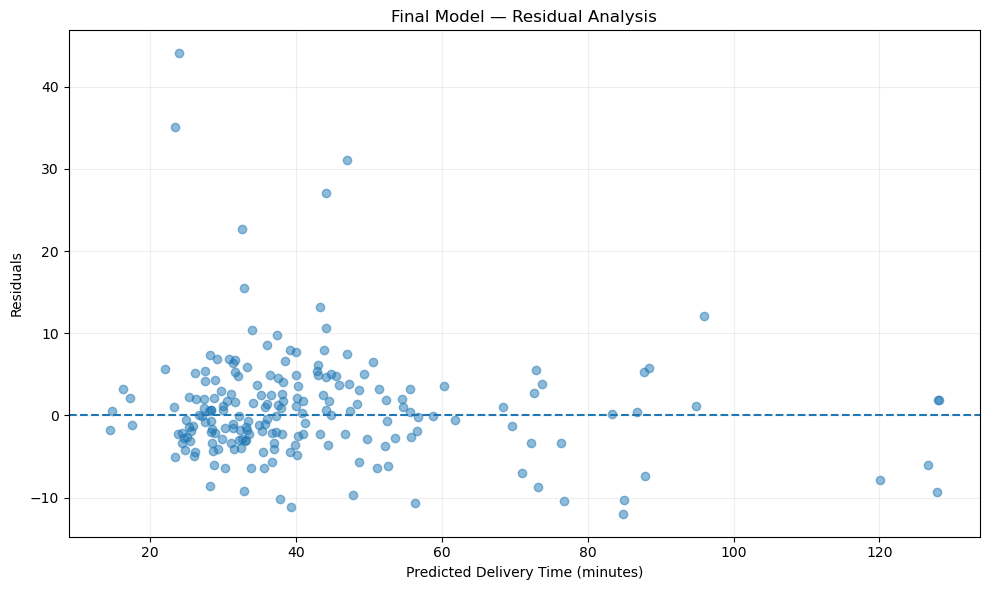

In [19]:
# ============================================================
# BLOCK 17 — FINAL MODEL RESIDUAL ANALYSIS
# ============================================================

final_residuals = (
    y_test - final_test_pred
)

plt.figure(
    figsize=(10, 6)
)

plt.scatter(
    final_test_pred,
    final_residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel(
    "Predicted Delivery Time (minutes)"
)

plt.ylabel(
    "Residuals"
)

plt.title(
    "Final Model — Residual Analysis"
)

plt.grid(
    alpha=0.2
)

plt.tight_layout()
plt.show()

In [20]:
# ============================================================
# BLOCK 18 — FEATURE IMPORTANCE
# ============================================================

# Get preprocessing step
final_preprocessor = final_model[
    "preprocessor"
]

# Get transformed feature names
feature_names = (
    final_preprocessor
    .get_feature_names_out()
)

# Get model feature importance
importance = (
    final_model["model"]
    .feature_importances_
)

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .head(20)
)

print(
    feature_importance
)

                             Feature  Importance
6    num__estimated_delivery_minutes    0.939878
4                   num__distance_km    0.004723
9      num__average_preparation_time    0.004700
13                num__driver_rating    0.004494
2              num__delivery_fee_eur    0.003612
5                 num__temperature_c    0.003503
10         num__average_daily_orders    0.003320
1                  num__subtotal_eur    0.003132
14         num__completed_deliveries    0.003100
11                          num__age    0.002975
15            num__average_speed_kmh    0.002835
12             num__years_experience    0.002066
8             num__restaurant_rating    0.002041
70                cat__city_Toulouse    0.001535
71                   cat__city_Turin    0.001451
3                  num__discount_eur    0.001153
7                   num__price_level    0.001096
44                  cat__city_Berlin    0.000750
106            cat__vehicle_type_Car    0.000742
0               num_

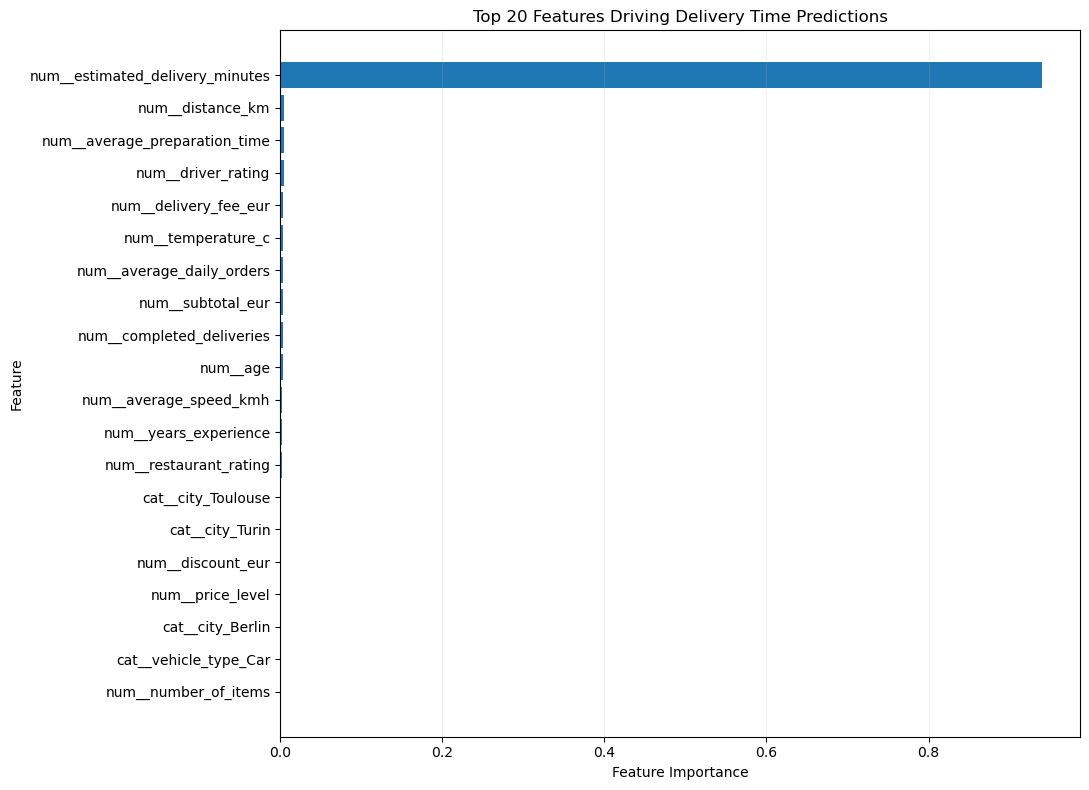

In [22]:
# ============================================================
# FEATURE IMPORTANCE CHART
# ============================================================

plt.figure(
    figsize=(11, 8)
)

plt.barh(
    feature_importance["Feature"][::-1],
    feature_importance["Importance"][::-1]
)

plt.xlabel(
    "Feature Importance"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Top 20 Features Driving Delivery Time Predictions"
)

plt.grid(
    axis="x",
    alpha=0.2
)

plt.tight_layout()
plt.show()

# ⚠️ NOTE — OUTDATED MODEL EVALUATION NOTEBOOK

This notebook contains an earlier version of the model evaluation and
final selection workflow.

It has been replaced by:

**`05 Evaluate Tune and Select Final Model.ipynb`**

## Why was this notebook replaced?

During the initial modeling process, `estimated_delivery_minutes` was
included as a predictive feature.

After reviewing the original EuroEats business problem, this feature
was removed from the primary regression model because:

- `estimated_delivery_minutes` represents the platform's existing ETA
  shown to the customer.
- The business objective is to independently predict actual delivery
  duration before dispatch.
- The initial model gave very high importance to this existing ETA,
  making the model heavily dependent on an already-existing prediction.
- Removing the feature allows the model to learn the operational
  factors that independently drive actual delivery time.

Therefore, the baseline models and final model results from this
notebook should NOT be used as the final project results.

## Current Modeling Workflow

The revised workflow uses the ML dataset saved as:

`EuroEats_ML_prepared_data.pkl`

The current model evaluation and final selection are performed in:

**`05 Evaluate Tune and Select Final Model.ipynb`**

The current workflow excludes:

`estimated_delivery_minutes`

This notebook is retained only for historical/reference purposes.

## Previous vs Revised Modeling Approach

### Previous model
Included:
`estimated_delivery_minutes`

The model achieved substantially better test performance, but the
feature dominated the model's predictions.

### Revised model
Excludes:
`estimated_delivery_minutes`

The revised model is used for the final project because it provides
an independent prediction of actual delivery duration based on
operational, restaurant, customer, driver, and order-related factors.

**Important:** Do not compare the old and revised model performance
as if they were equivalent models, because their feature sets are
different.

###### ------------------------------------------------------------------------------------------------------------ THE END ------------------------------------------------------------------------------------------------------------